COVID-19 PREDICTION MODEL



Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score
)
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Start timer for performance tracking
start_time = time.time()

DATA LOADING

In [2]:
print("Loading dataset...")
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab/covid_data_2020-2021.csv')

Loading dataset...
Mounted at /content/drive


INITIAL DATA EXPLORATION, PROCESSING AND CLEANING


In [3]:
# Display basic information about the dataset

print("\nColumns in the dataset:")
print(df.columns.tolist())
print("\nSample of the data:")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

# Summary statistics
print("\nSummary statistics:")
print(df.describe())

##Data Preprocessing & Cleaning

# Drop rows with missing values
print("Dropping rows with missing values...")
df_cleaned = df.dropna()
print(f"Shape after dropping NAs: {df_cleaned.shape}")

# Encoding categorical variables
print("\nEncoding categorical variables...")
df_cleaned['gender'] = df_cleaned['gender'].map({'female': 0, 'male': 1})
df_cleaned['age_60_and_above'] = df_cleaned['age_60_and_above'].map({'No': 0, 'Yes': 1})

# Encode symptoms
symptom_cols = ['cough', 'fever', 'sore_throat', 'shortness_of_breath']
df_cleaned[symptom_cols] = df_cleaned[symptom_cols].replace({'no': 0, 'yes': 1})

# Convert 'corona_result' to binary classification with error handling
print("\nConverting corona_result to binary classification...")
def convert_result(x):
    if isinstance(x, str):
        return 1 if x.lower() == 'positive' else 0
    return x

df_cleaned['corona_result'] = df_cleaned['corona_result'].apply(convert_result)

# One-hot encode 'test_indication' column
print("\nOne-hot encoding test_indication column...")
df_cleaned = pd.get_dummies(df_cleaned, columns=['test_indication'], drop_first=True)

print("\nCleaned data sample:")
print(df_cleaned.head())


Columns in the dataset:
['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'corona_result', 'age_60_and_above', 'gender', 'test_indication']

Sample of the data:
    test_date  cough  fever  sore_throat  shortness_of_breath  head_ache  \
0  2021-10-11      0      0            0                    0          0   
1  2021-10-11      0      0            0                    0          0   
2  2021-10-11      0      0            0                    0          0   
3  2021-10-11      0      0            0                    0          0   
4  2021-10-11      0      0            0                    0          0   

  corona_result age_60_and_above  gender test_indication  
0      Negative              Yes  female           Other  
1      Negative              Yes    male           Other  
2      Negative               No  female           Other  
3      Negative              Yes  female           Other  
4      Negative              Yes  female           Ot

DATA VIZUALIZATION AND ANALYSIS

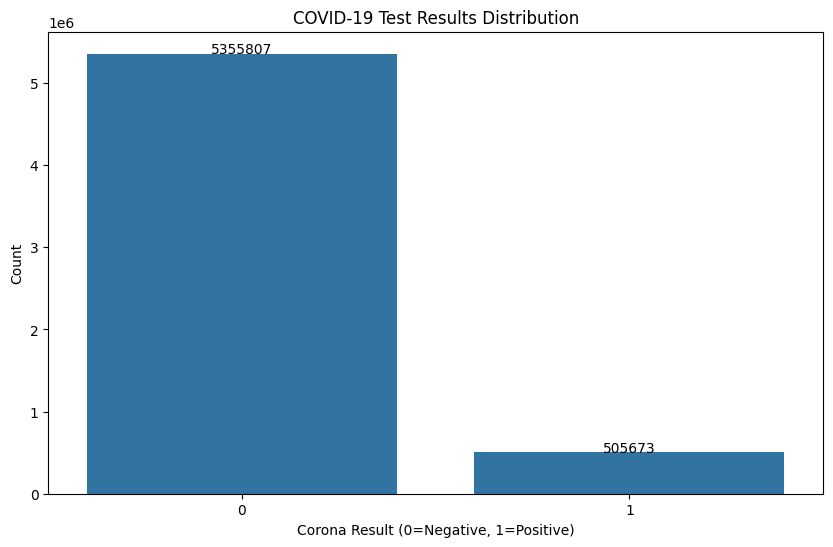


Class distribution:
corona_result
0    5355807
1     505673
Name: count, dtype: int64
corona_result
0    91.372947
1     8.627053
Name: proportion, dtype: float64


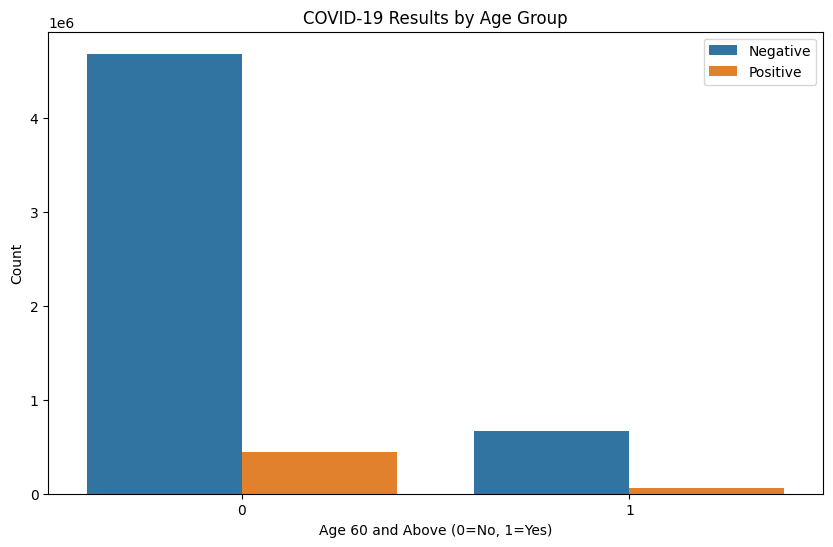

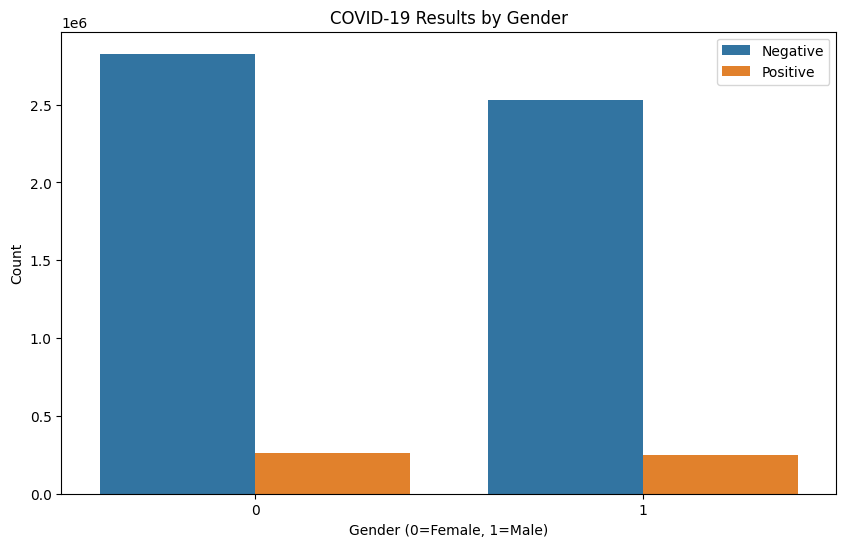

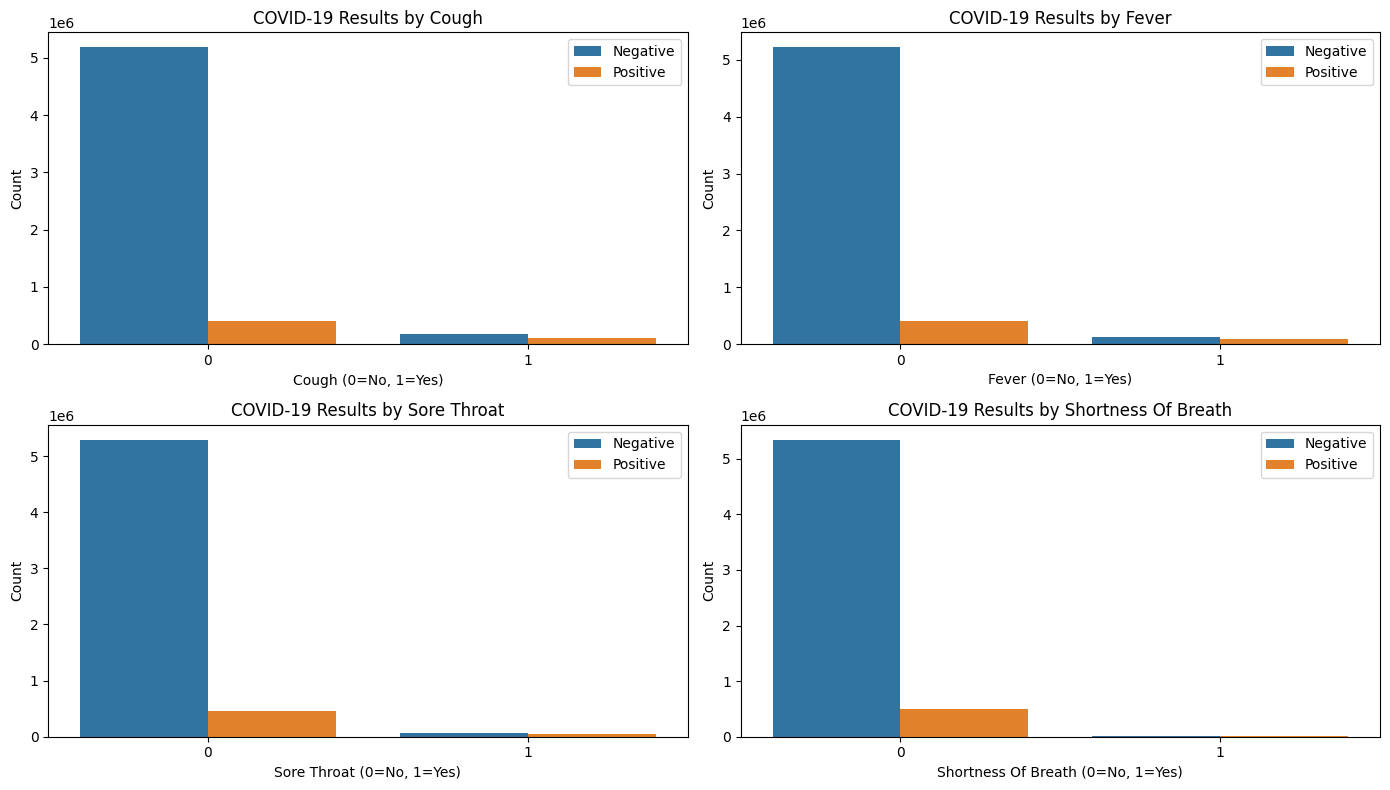

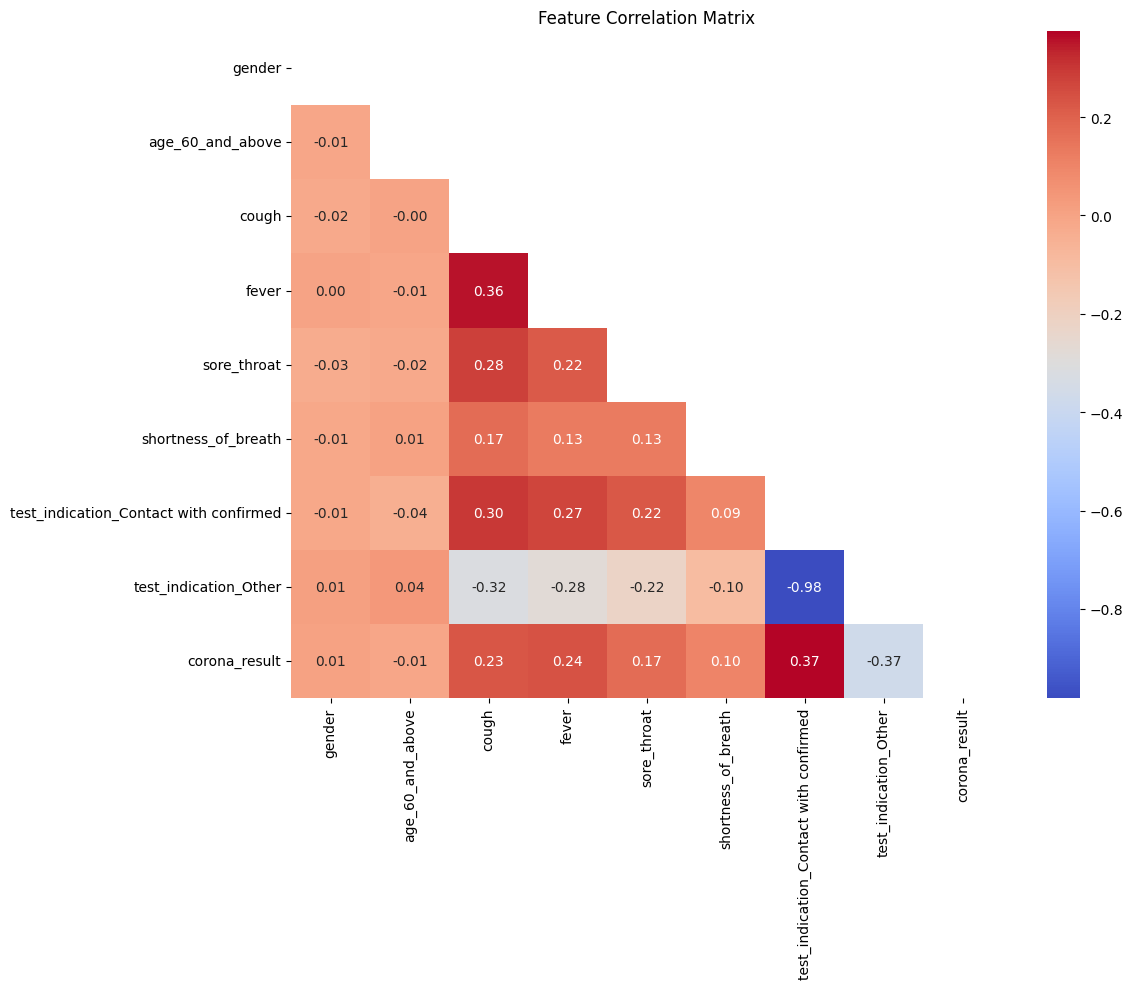

In [4]:

# Plot class distribution
plt.figure(figsize=(10, 6))
class_counts = df_cleaned['corona_result'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('COVID-19 Test Results Distribution')
plt.xlabel('Corona Result (0=Negative, 1=Positive)')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

print("\nClass distribution:")
print(df_cleaned['corona_result'].value_counts())
print(df_cleaned['corona_result'].value_counts(normalize=True) * 100)

# Age distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='age_60_and_above', hue='corona_result', data=df_cleaned)
plt.title('COVID-19 Results by Age Group')
plt.xlabel('Age 60 and Above (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(['Negative', 'Positive'])
plt.show()

# Gender distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', hue='corona_result', data=df_cleaned)
plt.title('COVID-19 Results by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.legend(['Negative', 'Positive'])
plt.show()

# Symptoms analysis
plt.figure(figsize=(14, 8))
for i, symptom in enumerate(symptom_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=symptom, hue='corona_result', data=df_cleaned)
    plt.title(f'COVID-19 Results by {symptom.replace("_", " ").title()}')
    plt.xlabel(f'{symptom.replace("_", " ").title()} (0=No, 1=Yes)')
    plt.ylabel('Count')
    plt.legend(['Negative', 'Positive'])
plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(12, 10))
feature_cols = ['gender', 'age_60_and_above'] + symptom_cols + \
               [col for col in df_cleaned.columns if col.startswith('test_indication_')] + \
               ['corona_result']
correlation_matrix = df_cleaned[feature_cols].corr()
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


SYPTOMS AND TRAIN TEST SPLIT


In [5]:
# Feature selection
features = ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'gender', 'age_60_and_above'] + \
           [col for col in df_cleaned.columns if col.startswith('test_indication_')]

print(f"Selected features: {features}")

X = df_cleaned[features]
y = df_cleaned['corona_result']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Show class distribution in train set
print("\nClass distribution in training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)


Selected features: ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'gender', 'age_60_and_above', 'test_indication_Contact with confirmed', 'test_indication_Other']
Training set shape: (4689184, 8)
Testing set shape: (1172296, 8)

Class distribution in training set:
corona_result
0    4284646
1     404538
Name: count, dtype: int64
corona_result
0    91.372955
1     8.627045
Name: proportion, dtype: float64


DATA BALANCING WITH SMOTE


Class distribution after SMOTE (training set):
corona_result
0    4284646
1    4284646
Name: count, dtype: int64
corona_result
0    50.0
1    50.0
Name: proportion, dtype: float64


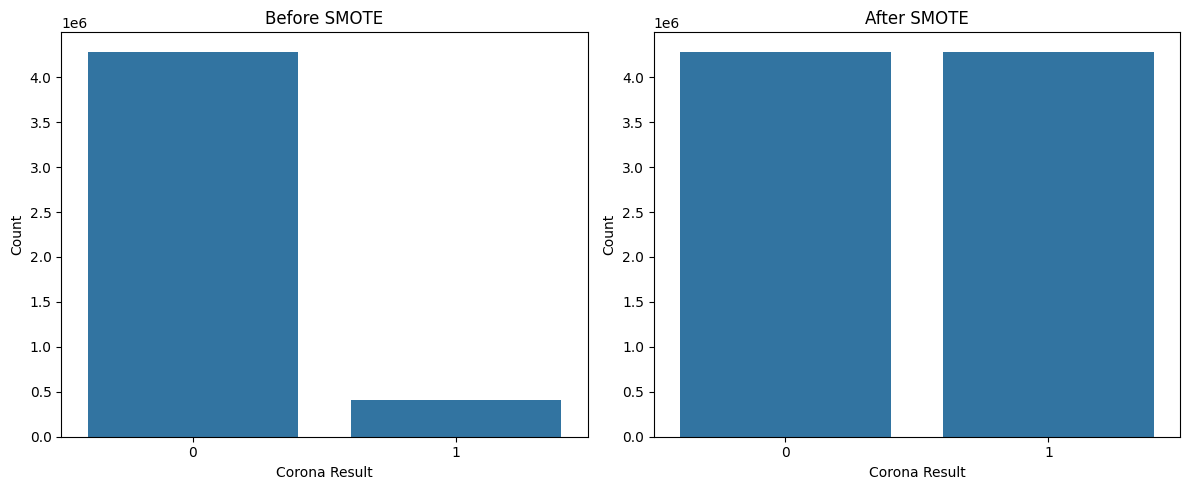

In [6]:
# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Show class distribution after applying SMOTE
print("\nClass distribution after SMOTE (training set):")
print(pd.Series(y_train_bal).value_counts())
print(pd.Series(y_train_bal).value_counts(normalize=True) * 100)

# Visualization of class distribution before and after SMOTE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Before SMOTE')
plt.xlabel('Corona Result')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_bal)
plt.title('After SMOTE')
plt.xlabel('Corona Result')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

MODEL BUILDING AND HYPERPARAMETER TUNING

In [7]:
# Model initialization
print("Initializing Random Forest model...")
rf_model = RandomForestClassifier(random_state=42)

# Hyperparameter tuning with GridSearchCV for RandomForest
'''param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}'''

# For faster execution, use a smaller grid
param_grid = {
     'n_estimators': [10, 10],
     'max_depth': [10, 20],
     'min_samples_split': [2, 5],
     'bootstrap': [True]
     }
# Use StratifiedKFold to maintain class balance in each fold
stratified_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Grid Search Cross-Validation
print("\nStarting GridSearchCV (this may take some time)...")
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=stratified_cv,
    n_jobs=-1,
    verbose=2,
    scoring='balanced_accuracy'
)

# Train the model
grid_search.fit(X_train_bal, y_train_bal)
print("GridSearchCV completed!")

# Best parameters and best score from Grid Search
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Use the best estimator found by GridSearchCV
best_rf_model = grid_search.best_estimator_


Initializing Random Forest model...

Starting GridSearchCV (this may take some time)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
GridSearchCV completed!

Best parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 10}
Best cross-validation score: 0.7595


MODEL EVALUATION


Confusion Matrix:
[[986684  84477]
 [ 40636  60499]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94   1071161
           1       0.42      0.60      0.49    101135

    accuracy                           0.89   1172296
   macro avg       0.69      0.76      0.72   1172296
weighted avg       0.91      0.89      0.90   1172296



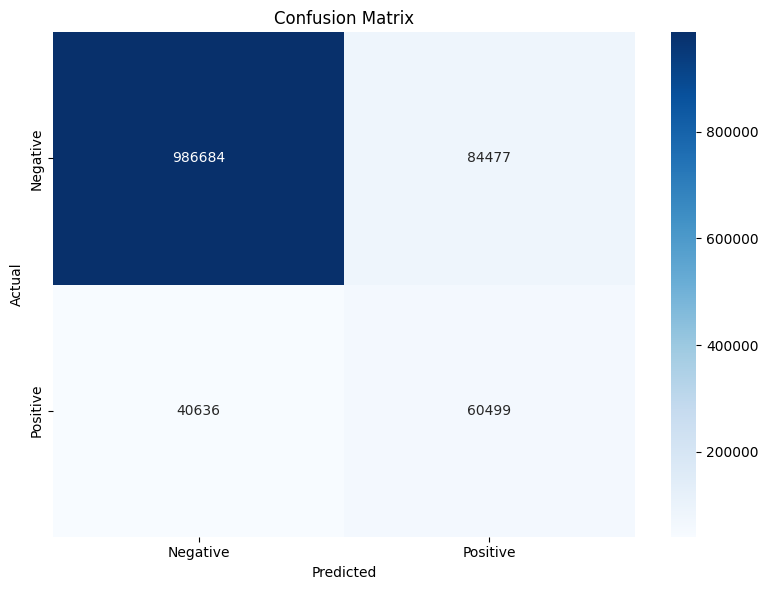

In [8]:
# Predict using the test data
y_pred = best_rf_model.predict(X_test)
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

ROC CURVE AND PRECISION-RECALL CURVE

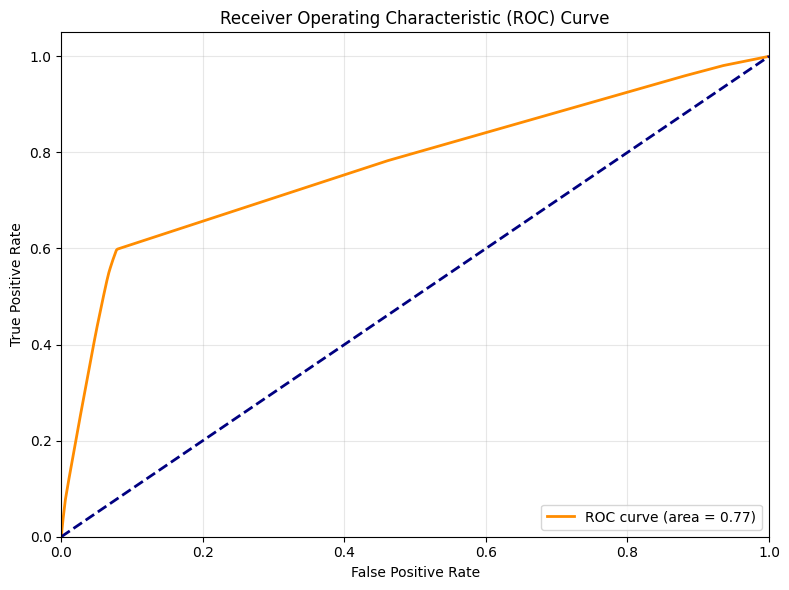

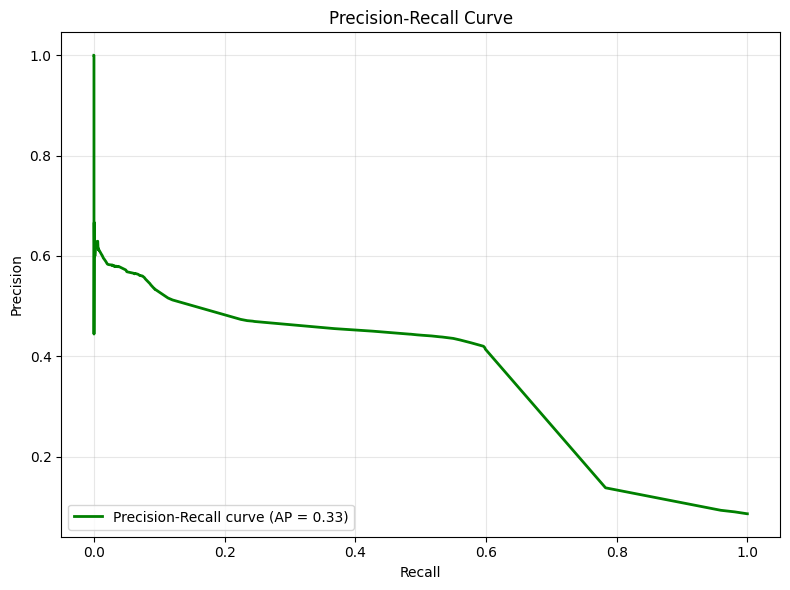

In [9]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2,
         label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

FEATURES IMPORTANT ANALYSIS

Feature importance ranking:
                                  Feature  Importance
6  test_indication_Contact with confirmed    0.308846
7                   test_indication_Other    0.294119
1                                   fever    0.173050
0                                   cough    0.139307
2                             sore_throat    0.063474
3                     shortness_of_breath    0.015653
5                        age_60_and_above    0.003345
4                                  gender    0.002207


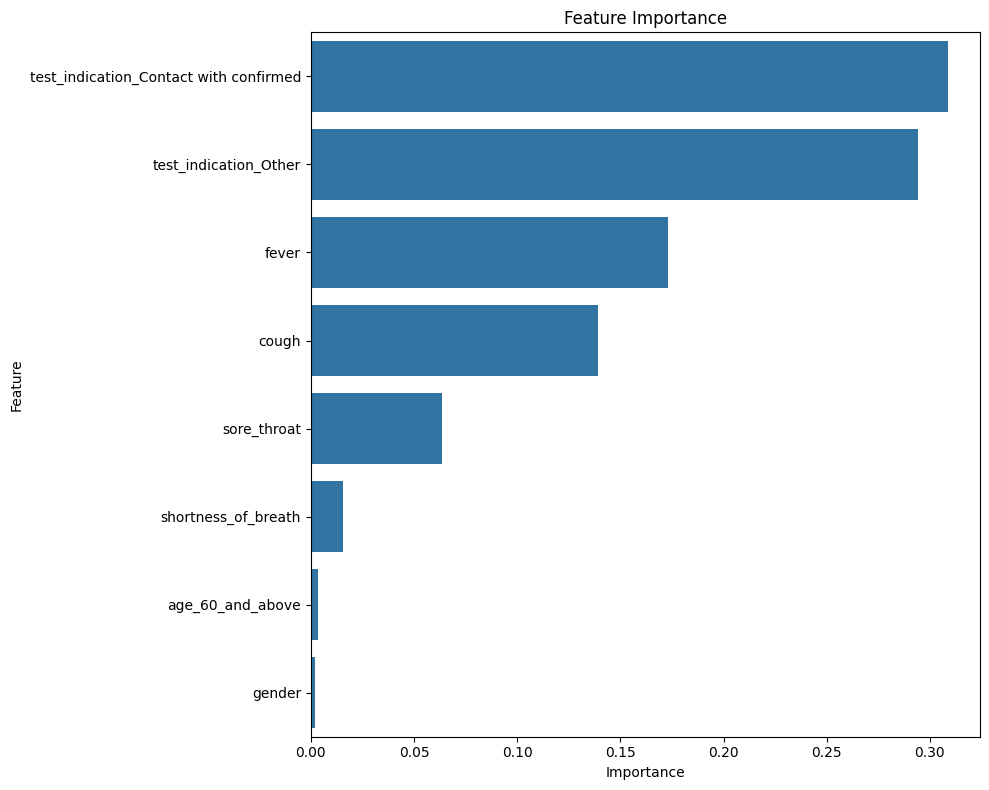

In [10]:

# Feature Importance Visualization
feature_importances = best_rf_model.feature_importances_
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Feature importance ranking:")
print(features_df)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()


MODEL SAVING AND DEPLOYMENT PREPARATION

In [11]:
# Import os for directory operations
import os

# Define the directory and file path
save_dir = '/content/drive/MyDrive/Colab'  # Changed from 'My Drive' to 'MyDrive'
model_path = os.path.join(save_dir, 'covid_prediction_model.pkl')

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Check if directory exists before saving
if os.path.exists(save_dir):
    print(f"Saving model to: {model_path}")
    try:
        # Save the model
        joblib.dump(best_rf_model, model_path)
        print(f"Model successfully saved to: {model_path}")
    except Exception as e:
        print(f"Error saving model: {e}")

        # Try an alternative location
        alt_model_path = '/content/covid_prediction_model.pkl'
        print(f"Trying alternative location: {alt_model_path}")
        joblib.dump(best_rf_model, alt_model_path)
        print(f"Model saved to alternative location: {alt_model_path}")
        model_path = alt_model_path
else:
    print(f"Warning: Directory {save_dir} does not exist.")
    # Save to content directory as fallback
    model_path = '/content/covid_prediction_model.pkl'
    print(f"Saving model to alternate location: {model_path}")
    joblib.dump(best_rf_model, model_path)
    print(f"Model saved to: {model_path}")

# Example of making predictions with the saved model
print("\nExample of using the saved model for prediction:")
print("Loading saved model...")
loaded_model = joblib.load(model_path)

# Create a sample patient data
sample_patient = {
    'cough': 1,  # Yes
    'fever': 1,  # Yes
    'sore_throat': 0,  # No
    'shortness_of_breath': 1,  # Yes
    'gender': 1,  # Male
    'age_60_and_above': 0  # No
}

# Add test_indication columns with zeros
for col in X.columns:
    if col not in sample_patient and col.startswith('test_indication_'):
        sample_patient[col] = 0

# Set one test indication to 1 (e.g., Contact with confirmed)
test_ind_cols = [col for col in X.columns if col.startswith('test_indication_')]
if test_ind_cols:
    sample_patient[test_ind_cols[0]] = 1

# Convert to DataFrame
sample_df = pd.DataFrame([sample_patient])

# Ensure sample_df has the same columns as the training data
for col in X.columns:
    if col not in sample_df.columns:
        sample_df[col] = 0

# Reorder columns to match training data
sample_df = sample_df[X.columns]

# Predict
prediction_prob = loaded_model.predict_proba(sample_df)[0, 1]
prediction = loaded_model.predict(sample_df)[0]

print("\nSample patient data:")
print(sample_patient)
print(f"\nPrediction: {'Positive' if prediction == 1 else 'Negative'}")
print(f"Probability of positive result: {prediction_prob:.2f}")

Saving model to: /content/drive/MyDrive/Colab/covid_prediction_model.pkl
Model successfully saved to: /content/drive/MyDrive/Colab/covid_prediction_model.pkl

Example of using the saved model for prediction:
Loading saved model...

Sample patient data:
{'cough': 1, 'fever': 1, 'sore_throat': 0, 'shortness_of_breath': 1, 'gender': 1, 'age_60_and_above': 0, 'test_indication_Contact with confirmed': 1, 'test_indication_Other': 0}

Prediction: Positive
Probability of positive result: 0.92


PERFORMANCE SUMMARY

In [12]:
# Calculate execution time
end_time = time.time()
execution_time = end_time - start_time
print(f"Total execution time: {execution_time:.2f} seconds")

# Summary of model performance
print("\nModel Performance Summary:")
print(f"- Model type: Random Forest")
print(f"- Best parameters: {grid_search.best_params_}")
print(f"- Cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"- Test set accuracy: {(y_pred == y_test).mean():.4f}")
print(f"- ROC AUC: {roc_auc:.4f}")
print(f"- Average Precision: {avg_precision:.4f}")
print("\nTop 5 most important features:")
for i, (feature, importance) in enumerate(zip(features_df['Feature'].head(5), features_df['Importance'].head(5))):
    print(f"{i+1}. {feature}: {importance:.4f}")


Total execution time: 2086.03 seconds

Model Performance Summary:
- Model type: Random Forest
- Best parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 10}
- Cross-validation accuracy: 0.7595
- Test set accuracy: 0.8933
- ROC AUC: 0.7734
- Average Precision: 0.3299

Top 5 most important features:
1. test_indication_Contact with confirmed: 0.3088
2. test_indication_Other: 0.2941
3. fever: 0.1731
4. cough: 0.1393
5. sore_throat: 0.0635
